In [1]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [2]:
import nltk 
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [4]:
label_map = {
    '__label__1': 0,  # negative
    '__label__2': 1,  # positive
    '__label__3': 2   # neutral
}

In [5]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Hp\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Hp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [6]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    tokens = word_tokenize(text.lower()) # tokenize and lowercase
    tokens = [t for t in tokens if t.isalpha()]  # remove punctuation
    tokens = [t for t in tokens if t not in stop_words] # remove stopwords
    tokens = [lemmatizer.lemmatize(t) for t in tokens] # lemmatize
    return " ".join(tokens)

texts = []
labels = []

In [7]:
with open("dataset.txt", "r", encoding="utf-8") as f:
    for line in f:
        parts = line.strip().split()
        label = parts[0]
        text = " ".join(parts[1:])
        texts.append(text)
        labels.append(label)

In [8]:
#cleaned reviews
processed_texts = [preprocess(t) for t in texts]
y = [label_map[l] for l in labels]

In [11]:
vectorizer = TfidfVectorizer(max_features=100000)
X = vectorizer.fit_transform(processed_texts)  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)

In [12]:
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

c:\Users\Hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [13]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [14]:
# Evaluate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9028


In [15]:
# Detailed classification report (precision, recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.50      0.61     13256
           1       0.88      0.82      0.85    105485
           2       0.91      0.95      0.93    281259

    accuracy                           0.90    400000
   macro avg       0.86      0.76      0.80    400000
weighted avg       0.90      0.90      0.90    400000



In [16]:
# Optional: Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[  6633    109   6514]
 [     5  86940  18540]
 [  1708  12004 267547]]


In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

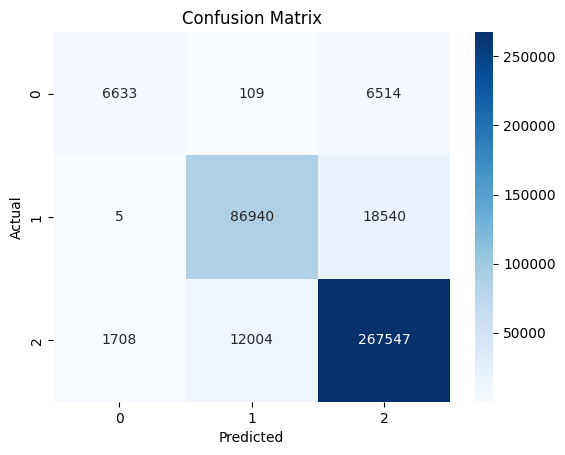

In [19]:
conf_m = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_m, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [22]:
# Predict a sentence
new_sentence = "It's a good product"

# Preprocess it (same as training)
preprocessed = preprocess(new_sentence)  # use the same preprocess function you used before

# Vectorize it using the same vectorizer
X_new = vectorizer.transform([preprocessed])

# Predict the label
predicted_label = model.predict(X_new)[0]

# Map prediction to text
label_map = {0: "Negative", 1: "Positive", 2: "Neutral"}
print("Prediction:", label_map[predicted_label])


Prediction: Positive


In [23]:
import joblib
joblib.dump(model, 'sentiment_model.pkl')
joblib.dump(vectorizer, 'vectorizer.pkl')

['vectorizer.pkl']

In [34]:
import joblib

# Load model and vectorizer
model = joblib.load('sentiment_model.pkl')
vectorizer = joblib.load('vectorizer.pkl')

# Transform and predict a new sentence
new_sentence = "I didn't like this, it was terrible."
preprocessed = preprocess(new_sentence)
X_new = vectorizer.transform([preprocessed])
prediction = model.predict(X_new)
label_map = {0: "Negative", 1: "Positive", 2: "Neutral"}
print("Prediction:", label_map[prediction[0]])



Prediction: Negative
